# 01 · Liked Songs Analysis

Our first look at real data: your Spotify **Liked Songs** library, pulled from
the Web API (`data/api/liked_songs.csv`). Each row is a song you saved, tagged
with the date you saved it.

We'll answer four questions:
1. **When** did you save music? (saves over time)
2. **Who** dominates your library? (top artists)
3. **How old** is the music you like? (release-year profile)
4. Do you save **fresh releases or dig up old stuff**? (discovery gap)

No genres or audio features here — Spotify restricts those for new apps — so
this is all behavioral and metadata analysis. That's the right first step, and
it teaches the core pandas moves.


## Setup

Import our libraries and make charts look nice.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# %matplotlib inline makes charts appear right below each cell.
%matplotlib inline
sns.set_theme(style="whitegrid")

SPOTIFY_GREEN = "#1DB954"


## Load and prepare the data

We read the CSV, then create a few **derived columns** — new columns computed
from existing ones. This is the bread-and-butter of analysis: the raw data
rarely has exactly the column you want to group or plot by, so you make it.


In [3]:
df = pd.read_csv("../data/api/liked_songs.csv")

# Parse the save timestamp into a real datetime we can do math on.
df["added_at"] = pd.to_datetime(df["added_at"], utc=True)

# Derived columns:
df["added_month"] = df["added_at"].dt.strftime("%Y-%m")   # e.g. "2025-03"
df["added_year"] = df["added_at"].dt.year
df["duration_min"] = df["duration_ms"] / 60000
# release_date can be "2015-10-16", "2015-10", or just "2015" — take the year.
df["release_year"] = pd.to_numeric(df["release_date"].astype(str).str[:4],
                                   errors="coerce")

print(f"Loaded {len(df)} liked songs")
df.head()


Loaded 62 liked songs


,added_at,track,artist,album,release_date,duration_ms,explicit,popularity,isrc,track_uri,added_month,added_year,duration_min,release_year
0,2026-06-03 10:02:25+00:00,Majorette,Beach House,Thank Your Lucky Stars,2015-10-16,240760,False,NaN,USSUB1514201,spotify:track:3XqgZV1iCMWafjUHgDarIK,2026-06,2026,4.012667,2015
1,2024-07-17 10:59:00+00:00,Heavy,The Marías,CINEMA,2021-06-25,253213,False,NaN,USAT22100694,spotify:track:1ShRHPAiiIrh0arZbSFmx1,2024-07,2024,4.220217,2021
2,2024-06-28 14:02:40+00:00,Kagefumi,百景,Standing Still In A Moving Scene,2006-06-07,294480,False,NaN,JPZ100600074,spotify:track:4VgGQi9FZMrNG4MuiONldI,2024-06,2024,4.908000,2006
3,2024-06-28 13:48:37+00:00,珊瑚海,"Jay Chou, Lara Liang",11月的蕭邦,2005-11-11,256333,False,NaN,TWK970500912,spotify:track:3Qj9Fy8BPbWmICTiNkuqB7,2024-06,2024,4.272217,2005
4,2024-02-29 14:57:24+00:00,Forevermore,Cuco,Forevermore,2021-05-07,174622,False,NaN,USUG12100983,spotify:track:4r4uSdJJKV8RIcNKH7pX54,2024-02,2024,2.910367,2021


## Quick overview

Before plotting anything, get a feel for the numbers. `.nunique()` counts
distinct values; `.mean()` averages; boolean columns average to a proportion.


In [4]:
n_songs = len(df)
n_artists = df["artist"].nunique()
first_save = df["added_at"].min().date()
last_save = df["added_at"].max().date()
avg_len = df["duration_min"].mean()
explicit_pct = df["explicit"].mean() * 100

print(f"Songs:            {n_songs}")
print(f"Unique artists:   {n_artists}")
print(f"Saved between:    {first_save} and {last_save}")
print(f"Avg song length:  {avg_len:.1f} min")
print(f"Explicit:         {explicit_pct:.0f}%")


Songs:            62
Unique artists:   52
Saved between:    2019-02-08 and 2026-06-03
Avg song length:  4.4 min
Explicit:         10%


## 1. Saves over time

How many songs did you like each month? We `groupby` the month and count.
One subtlety: months where you saved nothing won't appear on their own, so we
build the full range of months and fill the gaps with 0 — otherwise the chart
would silently skip quiet months and mislead you.


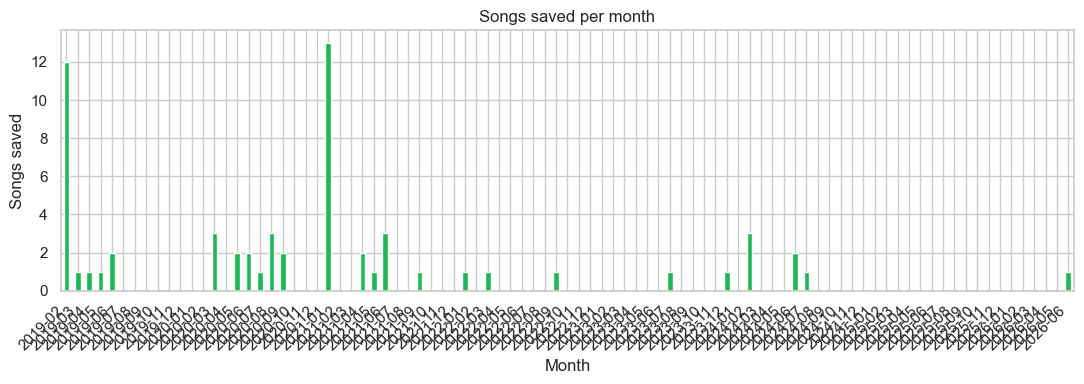

In [5]:
monthly = df.groupby("added_month").size()

# Build every month from first to last save, so gaps show as 0.
all_months = pd.period_range(start=df["added_month"].min(),
                             end=df["added_month"].max(), freq="M").astype(str)
monthly = monthly.reindex(all_months, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(kind="bar", ax=ax, color=SPOTIFY_GREEN)
ax.set_title("Songs saved per month")
ax.set_xlabel("Month")
ax.set_ylabel("Songs saved")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 2. Who dominates your library?

`value_counts()` tallies how many times each artist appears — one of the most
useful one-liners in pandas. We take the top 15 and plot a horizontal bar chart
(easier to read artist names than vertical).


/var/folders/3w/80sltnfn6wxd55h6_5pbyj180000gn/T/ipykernel_29823/4033805313.py:8: UserWarning: Glyph 30334 (\N{CJK UNIFIED IDEOGRAPH-767E}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3w/80sltnfn6wxd55h6_5pbyj180000gn/T/ipykernel_29823/4033805313.py:8: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 30334 (\N{CJK UNIFIED IDEOGRAPH-767E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


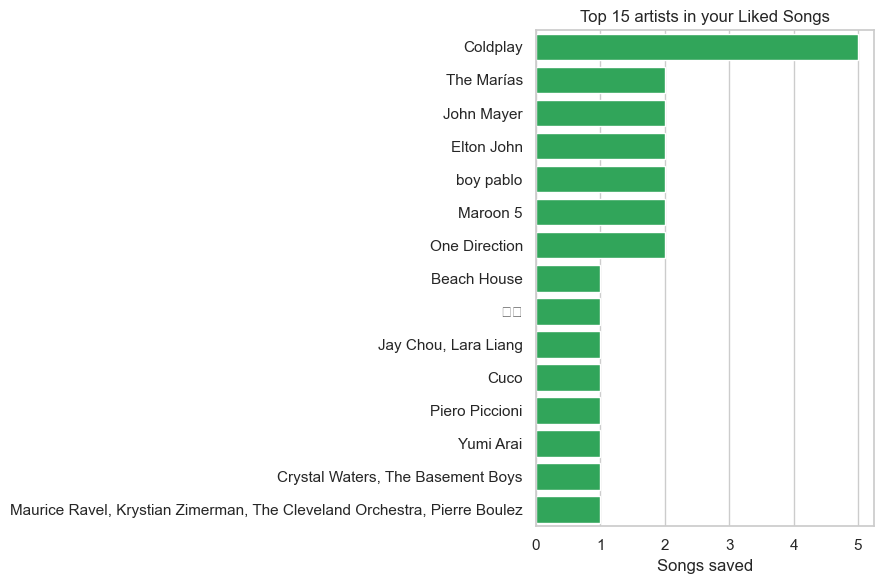

Your top 10 artists make up 32% of your library.


In [6]:
top_artists = df["artist"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_artists.values, y=top_artists.index, color=SPOTIFY_GREEN, ax=ax)
ax.set_title("Top 15 artists in your Liked Songs")
ax.set_xlabel("Songs saved")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# How top-heavy is your taste? Share of library from your top 10 artists.
top10_share = df["artist"].value_counts().head(10).sum() / len(df) * 100
print(f"Your top 10 artists make up {top10_share:.0f}% of your library.")


## 3. How old is the music you like?

Using each song's release year, we can see whether you lean new or vintage.


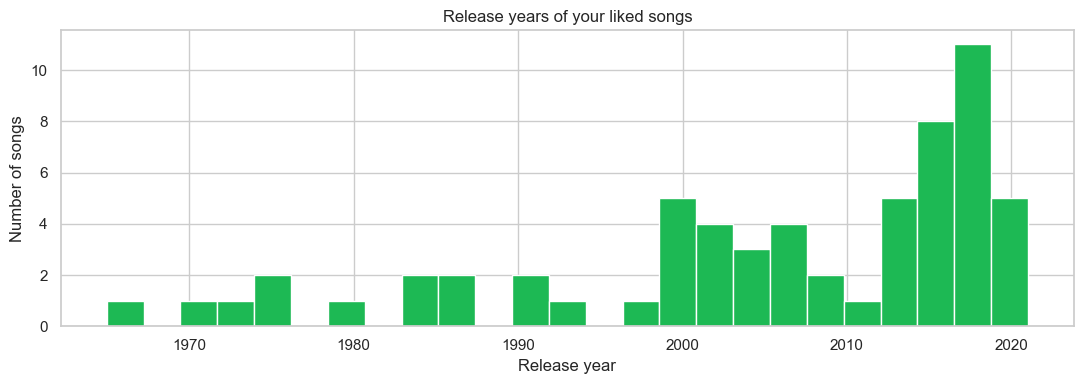

Oldest: 1965   Newest: 2021   Median: 2008


In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
df["release_year"].plot(kind="hist", bins=25, color=SPOTIFY_GREEN,
                        edgecolor="white", ax=ax)
ax.set_title("Release years of your liked songs")
ax.set_xlabel("Release year")
ax.set_ylabel("Number of songs")
plt.tight_layout()
plt.show()

print(f"Oldest: {int(df['release_year'].min())}   "
      f"Newest: {int(df['release_year'].max())}   "
      f"Median: {int(df['release_year'].median())}")


## 4. Fresh releases or digging up old stuff?

The **discovery gap** = the year you saved a song minus the year it was released.
A gap near 0 means you save new releases; a large gap means you discover older
music. This kind of *derived insight* — combining two columns into a new signal
— is exactly the sort of thing that makes a "comprehensive" Wrapped interesting.


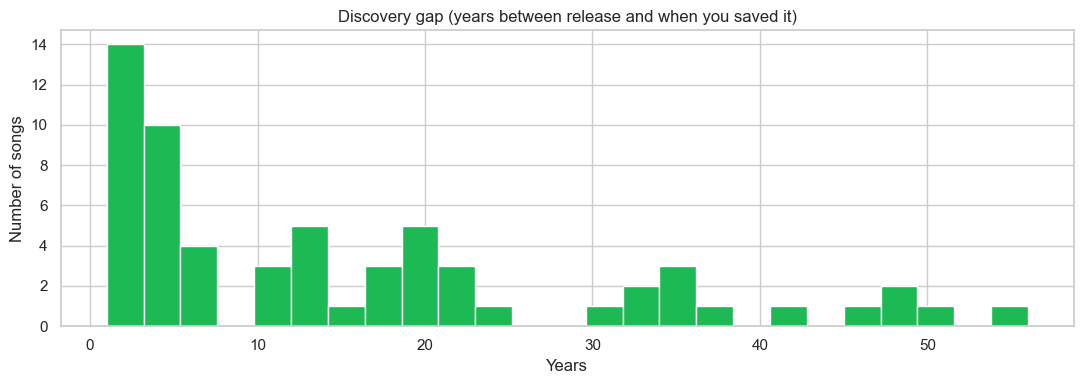

Median discovery gap: 12 years
(0 = you tend to save new releases; larger = you dig up older music.)


In [8]:
df["discovery_gap"] = df["added_year"] - df["release_year"]

fig, ax = plt.subplots(figsize=(11, 4))
df["discovery_gap"].plot(kind="hist", bins=25, color=SPOTIFY_GREEN,
                         edgecolor="white", ax=ax)
ax.set_title("Discovery gap (years between release and when you saved it)")
ax.set_xlabel("Years")
ax.set_ylabel("Number of songs")
plt.tight_layout()
plt.show()

median_gap = df["discovery_gap"].median()
print(f"Median discovery gap: {median_gap:.0f} years")
print("(0 = you tend to save new releases; larger = you dig up older music.)")


## Wrap-up

You just did real data analysis on your own listening: loading a CSV, building
derived columns, `groupby`/`value_counts` aggregations, and four charts.

**Things to try yourself:**
- Change `.head(15)` to `.head(20)` in the artists chart.
- Plot the **duration** distribution (`df["duration_min"].plot(kind="hist")`).
- Find your most-saved **album** (hint: `value_counts` on the `album` column).

**Next up:** when your full streaming-history export arrives, we get *plays*
(not just saves) — enabling time-of-day heatmaps, skip analysis, and the mood
work once we join audio features by ISRC.
